 # **Proyecto Final - Etapa II - Machine Learning 🧠** | **Clasificación de ritmo cardiaco 🖤**
---

> Miguel Contardo Ramos - 18/06/2025

---

## **1. Limpieza de los datos**
- Antes de entrenar un modelo de ML, se debe realizar una limpieza de los datos existentes. En este punto se trabajará con la detección y tratamiento de datos faltantes, extremos y normalización de los datos.

### **Detección y tratamiento de datos faltantes**

In [26]:
import pandas as pd

df = pd.read_csv("resultados_filtrados.csv")

#Detección de datos faltantes
print("Cantidad de datos faltantes por columna:")
print(df.isnull().sum())

Cantidad de datos faltantes por columna:
id         0
mean_rr    0
std_rr     0
skew_rr    0
kurt_rr    0
label      0
dtype: int64


> Como se observa, no hay datos faltantes, por lo que podemos pasar al siguiente paso.

### **Detección y tratamiento de valores extremos (outliers)**

- Para realizar la detección de outliers, se utilizará un enfoque multivariado, es decir, la detección se logra mediante el análisis de todas las características (variables) del dataset. Para lograr esto, se utiliza el criterio LOF (Local Outlier Factor), el cual se basa en calcular la densidad en ciertos lugares del dataset. Dicha densidad es clave para generar un puntaje LOF, que se usa para verificar si un registro es atípico o no.

- Para utilizar esta funcionalidad en python, se debe instalar lo siguiente:

In [15]:
%pip install scikit-learn pandas matplotlib seaborn xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.3/150.0 MB 6.7 MB/s eta 0:00:23
    --------------------------------------- 2.4/150.0 MB 6.7 MB/s eta 0:00:23
    --------------------------------------- 3.4/150.0 MB 5.4 MB/s eta 0:00:27
   - -------------------------------------- 4.7/150.0 MB 5.7 MB/s eta 0:00:26
   - -------------------------------------- 5.8/150.0 MB 5.7 MB/s eta 0:00:26
   - -------------------------------------- 7.1/150.0 MB 5.7 MB/s eta 0:00:25
   -- ------------------------------------- 8.4/150.0 MB 5.8 MB/s eta 0:00:25
   -- ------------------------------------- 9.4/150.0 MB 5.7 MB/s eta 0:00:25
   -- ------------------------------------- 11.0/150.0 MB 5.8 MB/s eta 0:00:24
   --- ------------------------------------ 12.3/150.0 MB 5.9 MB/s eta 0:00:24
   --- ------------------------------------ 13.9/150.0 MB 6.1 MB/s eta 0:00:23
   ---- ----------------------------------- 15.2/150.0 MB 6.0 MB/s e


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\maxoO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


- Detección de outliers mediante criterio LOF (10 vecinos)

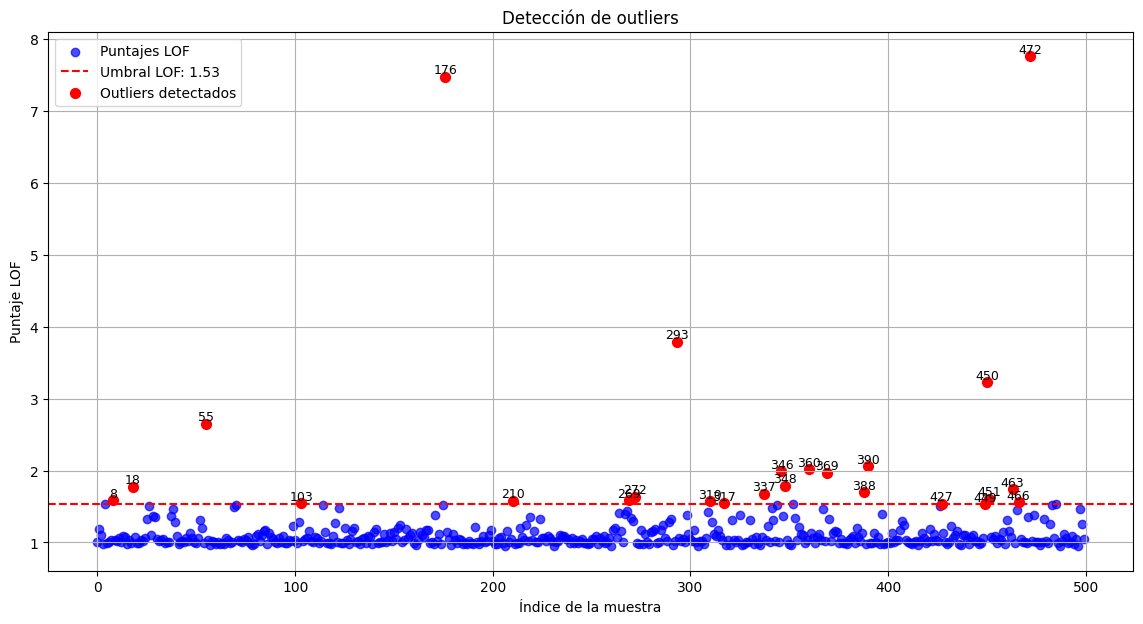

Cantidad de outliers detectados: 25

Datos extremos detectados (outliers):
     LOF_Score   mean_rr    std_rr   skew_rr    kurt_rr
8     1.591595  0.541049  0.104221  3.280478  15.679407
18    1.775518  1.305606  0.961709  1.394277   0.733113
55    2.651559  0.497119  0.181545  5.257884  32.430664
103   1.547208  0.497232  0.085378  3.431078  12.056427
176   7.470557  4.022500  1.814551 -1.097509  -0.715880
210   1.583235  0.399909  0.036243  2.993601  12.839985
269   1.591587  0.677209  0.225417  3.983909  18.753607
272   1.633658  0.872929  0.037549  2.850608  14.184412
293   3.792388  0.639275  0.066046  5.656495  42.511561
310   1.569798  0.805463  0.422466  3.689894  12.149316
317   1.549909  0.657593  0.343133  3.492514  13.142199
337   1.675839  1.079600  0.193180  3.891460  15.385770
346   1.991665  1.333725  0.794236  1.090535  -0.306118
348   1.788230  1.288696  0.451079  1.074054  -0.638983
360   2.017860  0.625145  0.116544  4.630341  24.576531
369   1.969297  0.699123  0.1

In [23]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
X = df[columnas_numericas].values
y = df["label"].values

# Parámetros LOF
contamination = 0.05  
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)

# Aplicar LOF
y_pred = lof.fit_predict(X)
scores = -lof.negative_outlier_factor_ 


df_outliers = df
# Agregar resultados al dataframe
df_outliers['LOF_Score'] = scores
df_outliers['Outlier'] = y_pred

# Calcular el umbral real basado en la contaminación
threshold = np.percentile(scores, 100 * (1 - contamination))

# Gráfico: puntajes LOF
plt.figure(figsize=(14, 7))
plt.scatter(range(len(scores)), scores, color='blue', alpha=0.7, label='Puntajes LOF')

# Dibujar la línea de umbral
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Umbral LOF: {threshold:.2f}')

# Resaltar los outliers en rojo
outlier_indices = np.where(scores > threshold)[0]
plt.scatter(outlier_indices, scores[outlier_indices], color='red', s=50, label='Outliers detectados')

# Etiquetar los outliers
for idx in outlier_indices:
    plt.text(idx, scores[idx], str(idx), fontsize=9, color='black', ha='center', va='bottom')

plt.title('Detección de outliers')
plt.xlabel('Índice de la muestra')
plt.ylabel('Puntaje LOF')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar resumen
print(f"Cantidad de outliers detectados: {len(df_outliers[df_outliers['Outlier'] == -1])}")
print("\nDatos extremos detectados (outliers):")
print(df_outliers[df_outliers['Outlier'] == -1][['LOF_Score'] + list(columnas_numericas)])

> Ahora veremos el "label" que tenía cada outlier


Distribución de clases dentro de los outliers detectados:
label
N    19
A     6
Name: count, dtype: int64


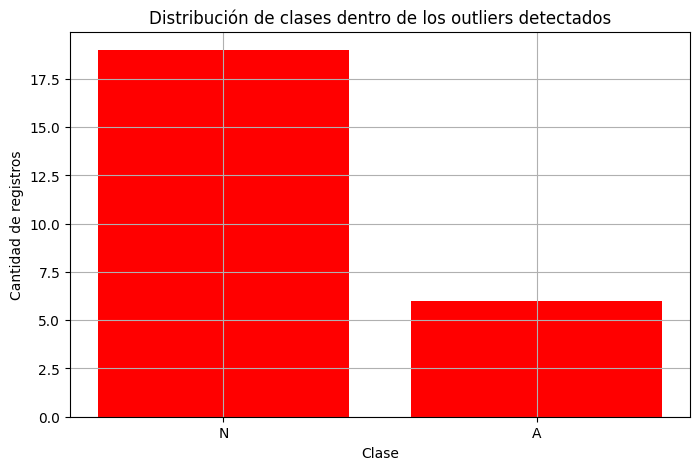

In [3]:
# Contar cuántos registros de cada clase hay dentro de los outliers
conteo_outliers_por_clase = df_outliers[df_outliers['Outlier'] == -1]['label'].value_counts()

print("\nDistribución de clases dentro de los outliers detectados:")
print(conteo_outliers_por_clase)

# Graficar la distribución de clases dentro de los outliers
plt.figure(figsize=(8, 5))
plt.bar(conteo_outliers_por_clase.index.astype(str), conteo_outliers_por_clase.values, color='red')
plt.title('Distribución de clases dentro de los outliers detectados')
plt.xlabel('Clase')
plt.ylabel('Cantidad de registros')
plt.grid(True)
plt.show()

- Como podemos ver, hay 19 outliers que pertenecen a la clase "N" y 6 a la A. En este caso, eliminar estos outliers significa un desbalance de clases en el dataset. 
- Otro punto importante es evaluar si estos datos atípicos son fundamentales para el estudio, ya que quizás puedan haber electrocardiogramas con las mismas características, y entrenar el modelo sin estos datos podría ser perjudicial.
- Como solo estamos usando una muestra, es posible que estos datos no sean tan atípicos como se podría pensar en un principio, ya que esta muestra quizás no sea la mejor representación de los datos totales. 

---

## **2. Entrenamiento y Evaluación de mejor algoritmo a utilizar**

- En esta sección, se entrenarán distintos modelos supervisados de ML: Regresión lineal, Random Forest, Gradient Boosting, Xtreme Gradient Boosting, SVM, k-NN y MLP, capturando los resultados de cada uno de ellos mediante distintas métricas y evaluando cuál sería el modelo a utilizar según esas características.
- Se utilizará el método de validación cruzada, con 10 particiones.
- Se escalarán los datos para aquellos modelos en que sea necesario hacerlo.

🔍 Buscando mejores hiperparámetros para: Logistic Regression
✔ Mejor score F1_macro (validación cruzada): 0.8016
✔ Score F1_macro en todo el dataset: 0.8040
✔ Mejor combinación de hiperparámetros: {'model__C': 10}

🔍 Buscando mejores hiperparámetros para: Random Forest
✔ Mejor score F1_macro (validación cruzada): 0.8613
✔ Score F1_macro en todo el dataset: 0.9258
✔ Mejor combinación de hiperparámetros: {'model__max_depth': 5, 'model__n_estimators': 100}

🔍 Buscando mejores hiperparámetros para: Gradient Boosting
✔ Mejor score F1_macro (validación cruzada): 0.8453
✔ Score F1_macro en todo el dataset: 0.9399
✔ Mejor combinación de hiperparámetros: {'model__learning_rate': 0.1, 'model__n_estimators': 50}

🔍 Buscando mejores hiperparámetros para: XGBoost


C:\Users\maxoO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [10:59:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✔ Mejor score F1_macro (validación cruzada): 0.8495
✔ Score F1_macro en todo el dataset: 0.9620
✔ Mejor combinación de hiperparámetros: {'model__learning_rate': 0.1, 'model__n_estimators': 50}

🔍 Buscando mejores hiperparámetros para: SVM
✔ Mejor score F1_macro (validación cruzada): 0.8756
✔ Score F1_macro en todo el dataset: 0.9080
✔ Mejor combinación de hiperparámetros: {'model__C': 1, 'model__gamma': 1}

🔍 Buscando mejores hiperparámetros para: k-NN
✔ Mejor score F1_macro (validación cruzada): 0.8577
✔ Score F1_macro en todo el dataset: 0.8820
✔ Mejor combinación de hiperparámetros: {'model__n_neighbors': 7}

🔍 Buscando mejores hiperparámetros para: MLP


C:\Users\maxoO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


✔ Mejor score F1_macro (validación cruzada): 0.8675
✔ Score F1_macro en todo el dataset: 0.9039
✔ Mejor combinación de hiperparámetros: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100,)}



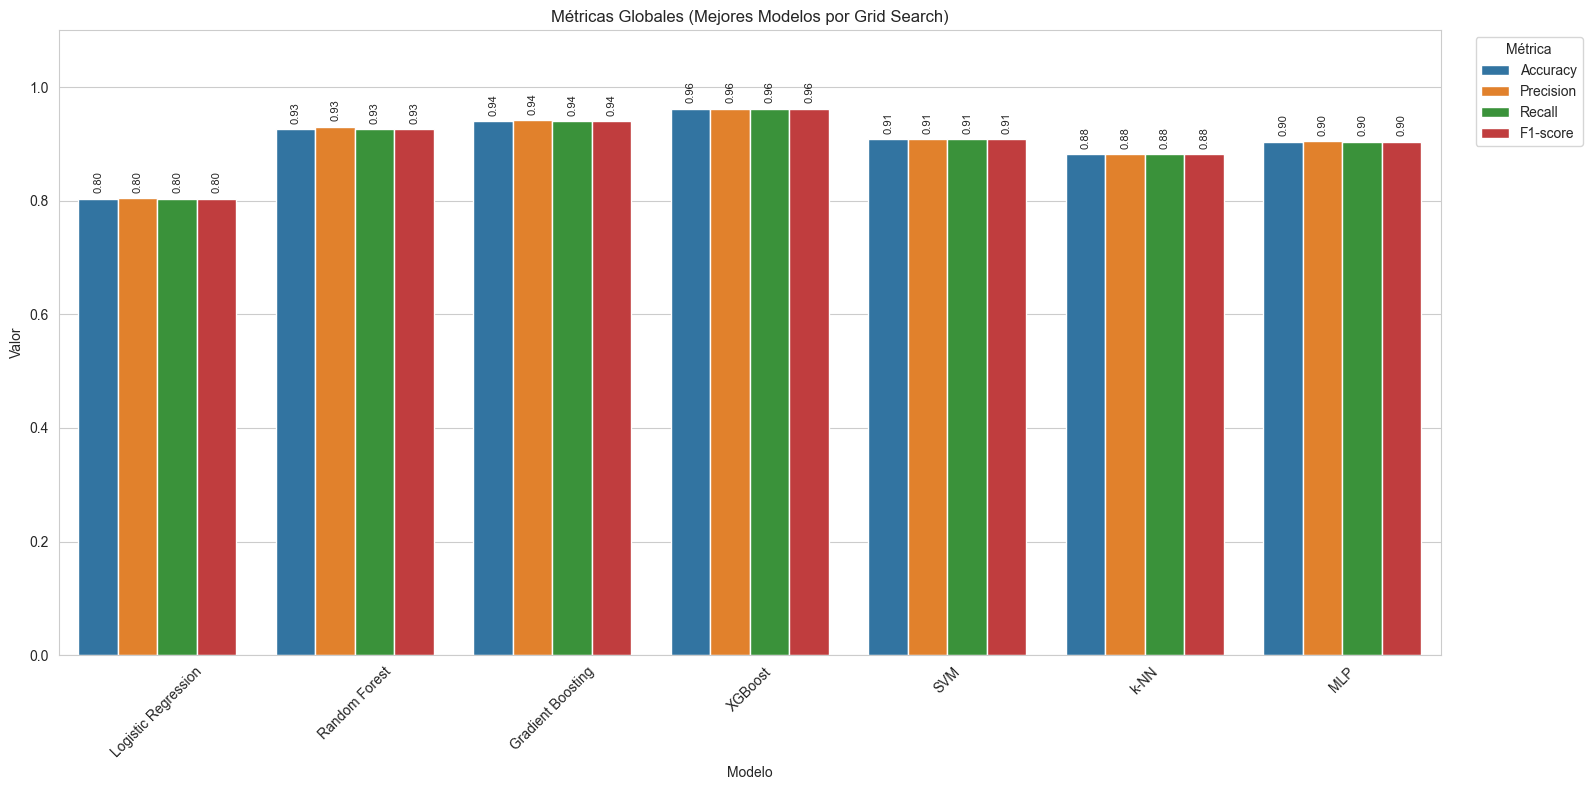

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ========================
# 1. Cargar y preparar datos
# ========================
df = pd.read_csv("resultados_filtrados.csv")
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
X = df[columnas_numericas]
le = LabelEncoder()
y = pd.Series(le.fit_transform(df["label"]))

# ========================
# 2. Definir modelos y grids
# ========================
pipelines_and_grids = {
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))]),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        Pipeline([('model', RandomForestClassifier(random_state=42))]),
        {
            'model__n_estimators': [50, 100],
            'model__max_depth': [5, 10]   # Limita la profundidad máxima aquí
        }
    ),
    'Gradient Boosting': (
        Pipeline([('model', GradientBoostingClassifier(random_state=42))]),
        {'model__n_estimators': [50, 100, 150],
         'model__learning_rate': [0.01, 0.1]}
    ),
    'XGBoost': (
        Pipeline([('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))]),
        {'model__n_estimators': [50, 100],
         'model__learning_rate': [0.01, 0.1]}
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()), ('model', SVC())]),
        {'model__C': [0.1, 1, 10],
         'model__gamma': [0.01, 0.1, 1]}
    ),
    'k-NN': (
        Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
        {'model__n_neighbors': [3, 5, 7]}
    ),
    'MLP': (
        Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(max_iter=500, random_state=42))]),
        {'model__hidden_layer_sizes': [(50,), (100,)],
         'model__alpha': [0.0001, 0.001]}
    )
}

# ========================
# 3. Cross-validation y GridSearchCV
# ========================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados = []
mejores_modelos = {}

for nombre, (pipeline, param_grid) in pipelines_and_grids.items():
    print(f"🔍 Buscando mejores hiperparámetros para: {nombre}")
    
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X, y)
    
    y_pred = grid.predict(X)
    
    # Guardar mejor modelo
    mejores_modelos[nombre] = grid.best_estimator_
    
    # Métrica F1 macro promedio validada (GridSearchCV)
    f1_macro_cv = grid.best_score_
    
    # Métricas calculadas sobre todo el dataset (puede estar inflado)
    report = classification_report(y, y_pred, output_dict=True, target_names=le.classes_)
    f1_macro_train = report['macro avg']['f1-score']
    
    print(f"✔ Mejor score F1_macro (validación cruzada): {f1_macro_cv:.4f}")
    print(f"✔ Score F1_macro en todo el dataset: {f1_macro_train:.4f}")
    print("✔ Mejor combinación de hiperparámetros:", grid.best_params_)
    print()
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': report['accuracy'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-score': f1_macro_train  # <-- Aquí cambió para usar el score en dataset completo
    })

# ========================
# 4. Visualización de resultados globales
# ========================
df_resultados = pd.DataFrame(resultados)

df_long = df_resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=df_long, x='Modelo', y='Valor', hue='Métrica', dodge=True)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height + 0.01),
                    ha='center', va='bottom', fontsize=8, rotation=90)

plt.title('Métricas Globales (Mejores Modelos por Grid Search)')
plt.ylabel('Valor')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



- Según estos resultados, podemos ver que Extreme Gradient Boosting tiene un desempeño mayor con este conjunto de datos.

### **Scores por clase**

C:\Users\maxoO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [11:00:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\maxoO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


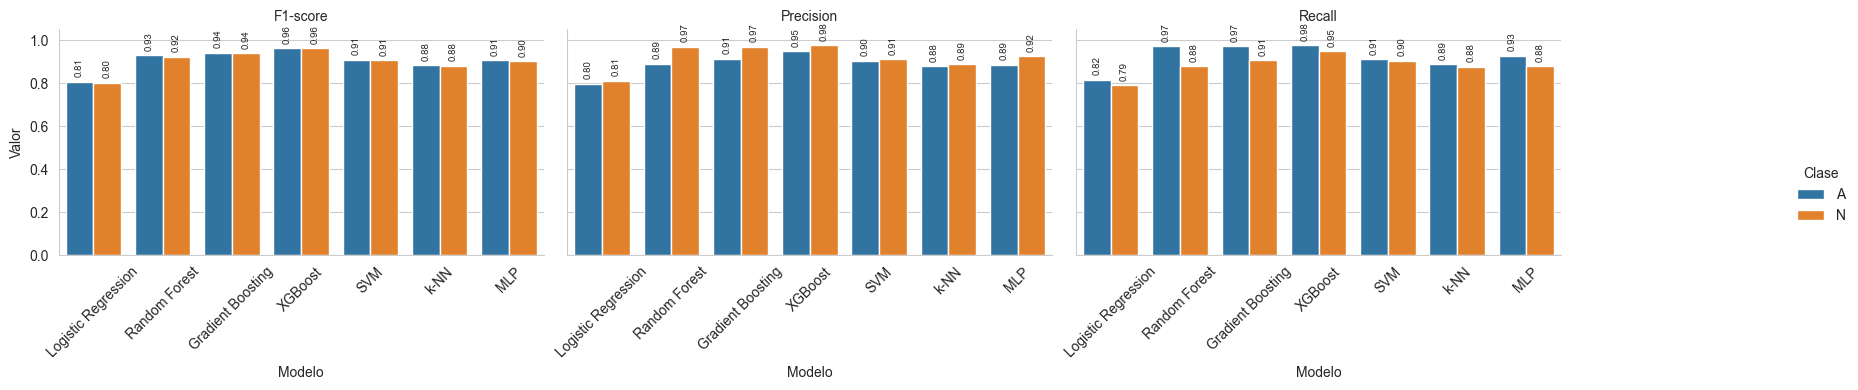

In [14]:
# Acumular métricas por clase de todos los modelos
resultados_por_clase = []

for nombre, (pipeline, param_grid) in pipelines_and_grids.items():
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X, y)
    y_pred = grid.predict(X)

    report = classification_report(y, y_pred, output_dict=True, target_names=le.classes_)
    
    # Iterar solo por clases (no por "accuracy", "macro avg", etc)
    for clase in le.classes_:
        f1 = report[clase]['f1-score']
        precision = report[clase]['precision']
        recall = report[clase]['recall']
        
        resultados_por_clase.append({
            'Modelo': nombre,
            'Clase': clase,
            'F1-score': f1,
            'Precision': precision,
            'Recall': recall
        })

# Convertir a DataFrame
df_clases = pd.DataFrame(resultados_por_clase)

# Pasar a formato largo para graficar con seaborn
df_clases_long = df_clases.melt(id_vars=['Modelo', 'Clase'], var_name='Métrica', value_name='Valor')

sns.set_style('whitegrid')

g = sns.catplot(
    data=df_clases_long, x='Modelo', y='Valor', hue='Clase',
    col='Métrica', kind='bar', height=5, aspect=1.2,
    palette='tab10', dodge=True
)

g.set_titles('{col_name}')
g.set_axis_labels('Modelo', 'Valor')
g.set(ylim=(0, 1.05))

# Rotar etiquetas del eje x para evitar superposición
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

    # Anotar valores encima de barras
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f'{height:.2f}',
                        (p.get_x() + p.get_width() / 2., height + 0.02),
                        ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout(rect=[0, 0, 0.85, 0.8])  # Deja espacio a la derecha para la leyenda
plt.show()

---

## **3. Matríz de confusión**

- En este punto se genera una matríz de confusión para las predicciones realizadas con todos los modelos, así visualizando los campos reales (true) con los predichos por el modelo (predicted).

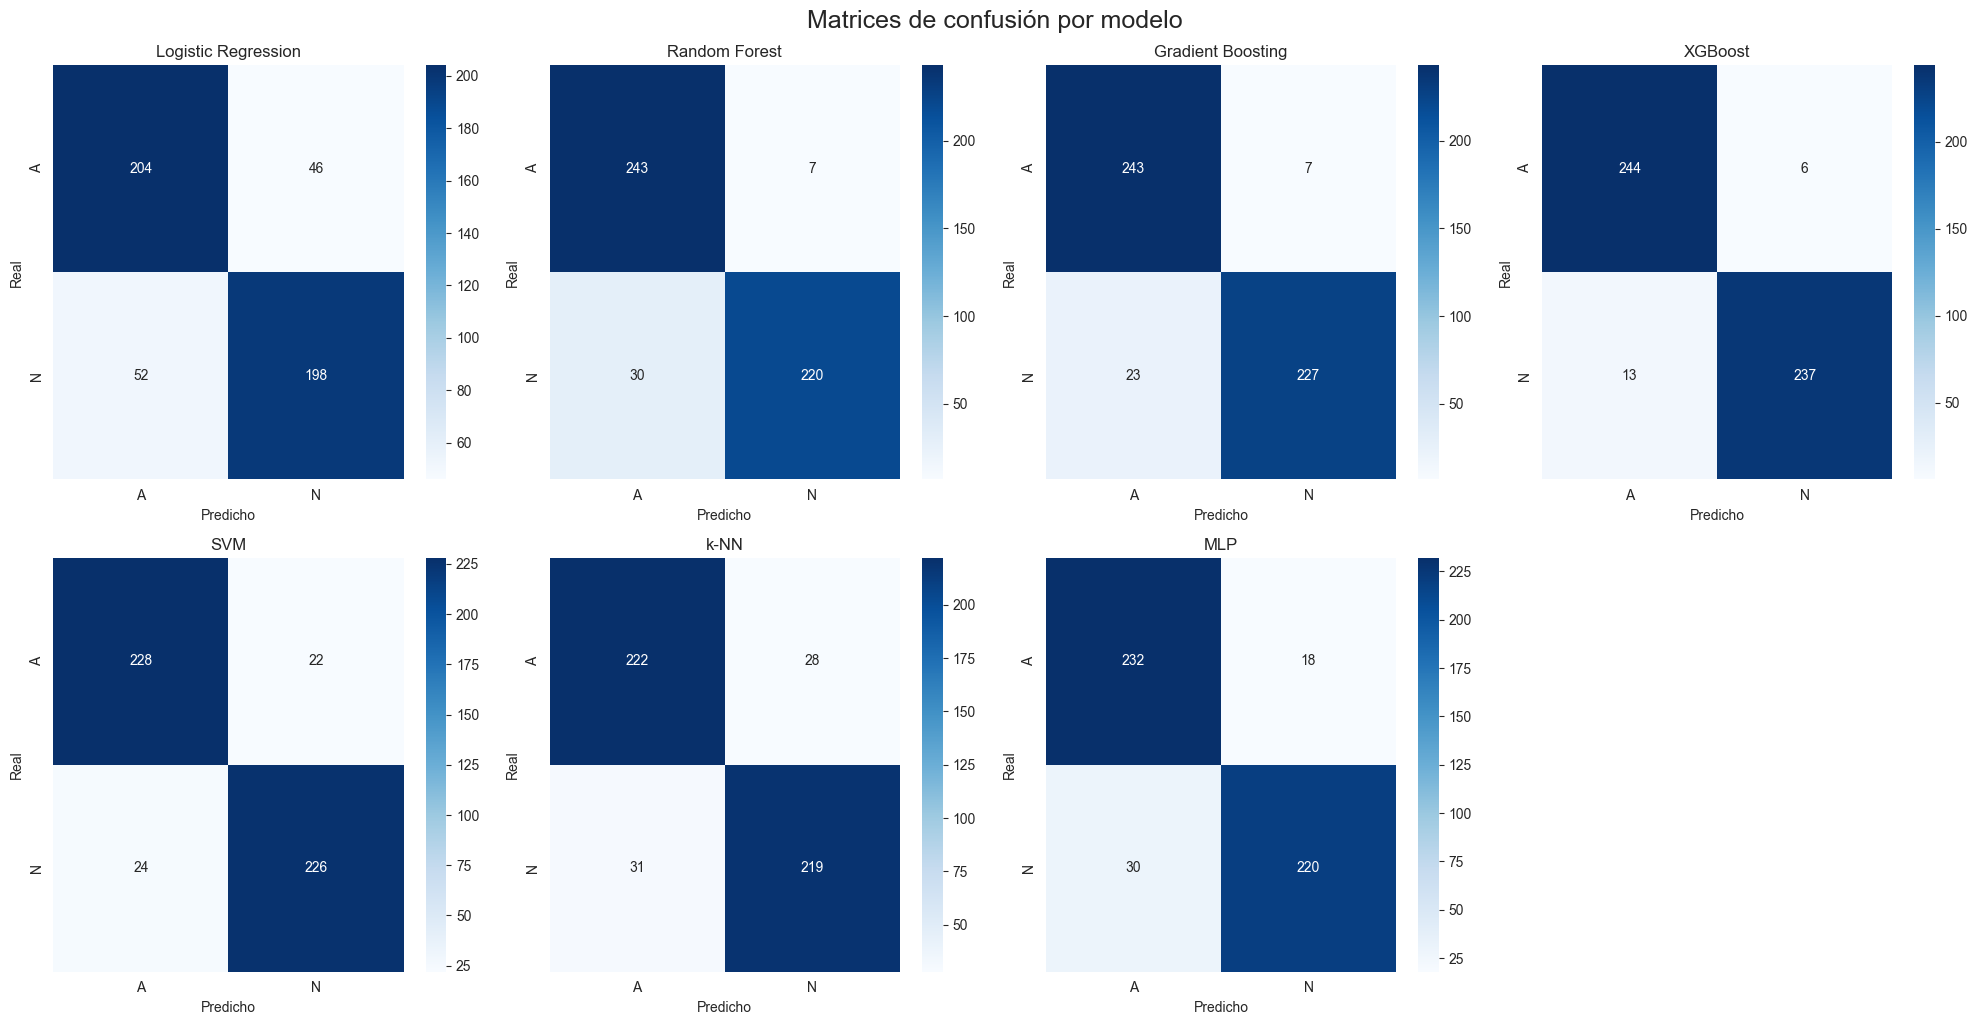

In [15]:
from sklearn.metrics import confusion_matrix

# ========================
# Matrices de confusión por modelo
# ========================
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()
labels = le.classes_

for i, (name, model) in enumerate(mejores_modelos.items()):
    y_pred = model.predict(X)
    matrix = confusion_matrix(y, y_pred, labels=le.transform(labels))
    
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicho")
    axes[i].set_ylabel("Real")

# Eliminar ejes vacíos si hay menos de 8 modelos
for j in range(len(mejores_modelos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Matrices de confusión por modelo", fontsize=18, y=1.02)
plt.show()



---


## **4. Conclusiones**

- Para concluir, nos encontramos con un dataset bastante limpio, sin valores faltantes y pocos valores extremos. De estos últimos se genera la duda si es que estos datos pueden no ser tan atípicos como lo refleja el criterio LOF, ya que solo trabajamos con una muestra que no sabemos si es representativa del total de los datos o no, además, desde el punto de vista clínico, tenemos una limitante al saber si es correcto eliminar o no estos supuestos datos extremos, ya que podrían ser casos especiales que pueden repetirse en el tiempo. Un fallo en esta área podría significar la vida o muerte de una persona, por lo que para este caso de estudio, se mantuvieron los outliers.

- Los modelos entrenados presentaron valores no tan alejados al desafío de physionet, al menos con XGB, aunque se presenta la misma incerteza del párrafo anterior, donde no sabemos si la muestra es lo suficientemente representativa del dataset completo. Quizás haya sido mejor trabajar con el total de los datos y realizar un sobremuestreo de la clase minoritaria, pero por temas de capacidad de cómputo y tiempo no se realizó.